# Tarea 1: el retrato de tu comuna

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

| | |
|---|---|
| **Integrante 1** | *Elismar Suarez \| 202304535-7* |
| **Integrante 2** | *Gonzalo Gutiérrez \| 202173604-2* |
| **Comuna** | *Las Condes* |
| **Comuna de contraste** | *Puente Alto* |

**Antes de empezar**

1. El archivo se entrega con el nombre `tarea1_apellido1_apellido2.ipynb`.
2. El notebook debe correr **de principio a fin** en el entorno del curso
   (`uv sync`), leyendo los datos desde `datos/eod_stgo/`.
3. Cada ítem tiene tres partes: las instrucciones, una o más celdas de código,
   y una celda de **Interpretación** donde va su respuesta. Un resultado
   correcto sin interpretación no otorga el puntaje completo.

**Regla transversal de la tarea**

Toda cifra que hable de la población debe estar **ponderada por el factor de
expansión que corresponde a la unidad analizada**, usando como universo mínimo el
**día laboral de temporada normal**: `Factor` para hogares,
`Factor_LaboralNormal` para personas y `FactorLaboralNormal` para viajes (los dos
últimos difieren solo en un guion bajo). Si deciden ampliar el universo (fin de
semana, temporada estival), deben declararlo y usar los factores correspondientes.
Una cifra muestral presentada como poblacional, o una cifra que no declara su
universo, descuenta en el ítem.

**Declaración**
Para el desarrollo de este informe, se ha decidido ampliar el universo de análisis desde el mínimo exigido de día laboral hacia la población total anual representada por la encuesta, para capturar el retrato poblacional completo sin restricciones de día o temporada.

## 0. Configuración

Esta celda deja listo lo que usarán en toda la tarea: las tres tablas
principales, la edad y el universo de día laboral. **Completen su comuna y
ejecútenla antes que todo lo demás.** Los nombres de comuna vienen en mayúsculas
y sin tildes (por ejemplo `"ESTACION CENTRAL"`).

Pandas no trae cuantiles ponderados: implementarlos es parte de la tarea.

In [432]:
def formato_chileno(numero):
    return f"{numero:,.0f}".replace(",", ".")

In [433]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

RUTA = "datos/eod_stgo/"

MI_COMUNA = "LAS CONDES"        # en mayusculas, como en Hogares.csv
COMUNA_CONTRASTE = "PUENTE ALTO"

hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)
personas = pd.read_csv(RUTA + "personas.csv", sep=";", decimal=",", low_memory=False)
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)

# La encuesta registra el anio de nacimiento; la edad se calcula al 2013.
personas["Edad"] = 2013 - personas["AnoNac"]

# Universo minimo de la tarea: dia laboral de temporada normal.
# El factor viene vacio (NaN) para quienes no pertenecen a ese universo
# (encuestados de fin de semana y de temporada estival): el filtro los excluye.
personas_lab = personas.dropna(subset=["Factor_LaboralNormal"]) #personas que viajan en dia laboral
viajes_lab = viajes.dropna(subset=["FactorLaboralNormal"]) 


print(f"hogares: {formato_chileno(len(hogares))} | personas: {formato_chileno(len(personas))} | viajes: {formato_chileno(len(viajes))}")
print(f"universo laboral: {formato_chileno(len(personas_lab))} personas | {formato_chileno(len(viajes_lab))} viajes")

hogares: 18.264 | personas: 60.054 | viajes: 113.591
universo laboral: 37.326 personas | 78.820 viajes


## Parte 1. Retrato numérico (25 puntos)

### 1. La muestra y a quién representa (5 pts)

**Instrucciones**

Reporten cuatro cifras para su comuna: cuántos hogares y cuántas personas fueron
encuestados, y a cuántos hogares y personas representan según los factores de
expansión.

En la interpretación, expliquen en una frase por qué "encuestados" y
"representados" responden preguntas distintas.

In [434]:
personasHogares = pd.merge(hogares, personas, on="Hogar", how="inner", suffixes=("_hogar", "_persona"))

personasLasCondes = personasHogares[personasHogares["Comuna"] == MI_COMUNA] # --> estas vars. son intermedias, se pueden renombrar facil
personasLasCondesReal = (personasHogares["Comuna"] == MI_COMUNA).sum() #total de personas las condes sin factor, no considera nan
personasLasCondesPond = personasLasCondes["Factor_persona"].sum() #total de personas representadas 

hogaresLasCondes = hogares[hogares["Comuna"] == MI_COMUNA] # --> estas vars. son intermedias, se pueden renombrar facil
hogaresLasCondesReal = (hogares["Comuna"] == MI_COMUNA).sum() #total de hogares de las condes sin factor, no considera nan
hogaresLasCondesPond = hogaresLasCondes["Factor"].sum()  #total de hogares representados 

tabla_muestra = pd.DataFrame({
    "Unidad": ["Personas", "Hogares"],
    "Encuestados": [
        personasLasCondesReal,
        hogaresLasCondesReal
    ],
    "Representados": [
        personasLasCondesPond,
        hogaresLasCondesPond
    ]
})

tabla_muestra["Representados"] = tabla_muestra["Representados"].round().astype(int)
tabla_muestra

,Unidad,Encuestados,Representados
0,Personas,2253,309184
1,Hogares,888,103108


**Interpretación:** Las personas y hogares encuestadas son distintas en cantidad a las representadas, debido a que estas segundas están ponderadas por un factor de representación en la que cada persona y hogar representa a tantas como el factor lo indique. Es decir, si el factor de la persona 1 es de 4, esta persona representa a 4 personas, con la misma información y respuestas que la original.

### 2. Composición (6 pts)

**Instrucciones**

Describan la composición de su comuna comparada con la del Gran Santiago:
la distribución por sexo (la proporción ponderada de cada categoría) y la edad
(mediana y percentiles 25 y 75 ponderados), para las dos unidades. La
ponderación usa el factor de la persona, dentro del universo que declararon al
inicio; si trabajan con el mínimo de día laboral, la celda de configuración ya
les deja `personas_lab` filtrado.

En la interpretación, expliquen en qué se parece y en qué difiere la composición
de su comuna respecto de la ciudad.

In [435]:
def cuantiles_ponderados(valores, pesos, cuantiles):
    datos = pd.DataFrame({
        "valor": valores,
        "peso": pesos
    }).dropna()

    datos = datos.sort_values("valor")
    peso_acumulado = datos["peso"].cumsum()
    peso_total = datos["peso"].sum()

    return np.interp(
        np.array(cuantiles) * peso_total,
        peso_acumulado,
        datos["valor"]
    )

#función para calcular cuantiles con peso (factor)

In [436]:
hombresLasCondes = personasLasCondes[personasLasCondes["Sexo"] == 1] #total de hombres de las condes
hombresLasCondesPond = hombresLasCondes["Factor_persona"].sum() #total de hombres representados 

mujeresLasCondes = personasLasCondes[personasLasCondes["Sexo"] == 2] #total de mujeres de las condes
mujeresLasCondesPond =mujeresLasCondes["Factor_persona"].sum() #total de mujeres representadas 


In [437]:
mujeres_stgo = personas[personas["Sexo"] == 2]
mujeres_stgoPond = mujeres_stgo["Factor"].sum()

hombres_stgo = personas[personas["Sexo"] == 1]
hombres_stgoPond = hombres_stgo["Factor"].sum()


total_lc_pond = mujeresLasCondesPond + hombresLasCondesPond
total_stgo_pond = mujeres_stgoPond + hombres_stgoPond

tabla_sexo = pd.DataFrame({
    "Unidad": ["Las Condes", "Las Condes", "Gran Santiago", "Gran Santiago"],
    "Sexo": ["Mujeres", "Hombres", "Mujeres", "Hombres"],
    "Encuestados": [
        len(mujeresLasCondes),
        len(hombresLasCondes),
        len(mujeres_stgo),
        len(hombres_stgo)
    ],
    "Representados": [
        mujeresLasCondesPond,
        hombresLasCondesPond,
        mujeres_stgoPond,
        hombres_stgoPond
    ],
    "Porcentaje (%)": [
        (mujeresLasCondesPond / total_lc_pond) * 100,
        (hombresLasCondesPond / total_lc_pond) * 100,
        (mujeres_stgoPond / total_stgo_pond) * 100,
        (hombres_stgoPond / total_stgo_pond) * 100
    ]
})

tabla_sexo["Representados"] = tabla_sexo["Representados"].round().astype(int)
tabla_sexo["Porcentaje (%)"] = tabla_sexo["Porcentaje (%)"].round(1)

display(tabla_sexo)

,Unidad,Sexo,Encuestados,Representados,Porcentaje (%)
0,Las Condes,Mujeres,1211,170805,55.2
1,Las Condes,Hombres,1042,138379,44.8
2,Gran Santiago,Mujeres,31679,3393718,51.0
3,Gran Santiago,Hombres,28375,3258017,49.0


In [438]:

edadLasCondes=cuantiles_ponderados(personasLasCondes["Edad"], personasLasCondes["Factor_persona"], [0.25, 0.50, 0.75])


edad_Mujeres_Las_Condes = cuantiles_ponderados(mujeresLasCondes["Edad"], mujeresLasCondes["Factor_persona"], [0.25, 0.50, 0.75])
edad_Hombres_Las_Condes = cuantiles_ponderados(hombresLasCondes["Edad"], hombresLasCondes["Factor_persona"], [0.25, 0.50, 0.75])


In [439]:
edadStgo = cuantiles_ponderados(personas["Edad"], personas["Factor"], [0.25, 0.50, 0.75])

tabla_edades = pd.DataFrame({
    "Unidad": [
        "Las Condes",
        "Gran Santiago"
    ],
    "Percentil 25": [
        edadLasCondes[0],
        edadStgo[0]
    ],
    "Mediana": [
        edadLasCondes[1],
        edadStgo[1]
    ],
    "Percentil 75": [
        edadLasCondes[2],
        edadStgo[2]
    ]
})

tabla_edades[[
    "Percentil 25",
    "Mediana",
    "Percentil 75"
]] = tabla_edades[[
    "Percentil 25",
    "Mediana",
    "Percentil 75"
]].round().astype(int)

display(tabla_edades)


edad_Mujeres_Stgo = cuantiles_ponderados(mujeres_stgo["Edad"], mujeres_stgo["Factor"], [0.25, 0.50, 0.75])
edad_Hombres_Stgo = cuantiles_ponderados(hombres_stgo["Edad"], hombres_stgo["Factor"], [0.25, 0.50, 0.75])


tabla_edades_sexo = pd.DataFrame({
    "Unidad": [
        "Las Condes",
        "Las Condes",
        "Gran Santiago",
        "Gran Santiago"
    ],
    "Sexo": [
        "Mujeres",
        "Hombres",
        "Mujeres",
        "Hombres"
    ],
    "Percentil 25": [
        edad_Mujeres_Las_Condes[0],
        edad_Hombres_Las_Condes[0],
        edad_Mujeres_Stgo[0],
        edad_Hombres_Stgo[0]
    ],
    "Mediana": [
        edad_Mujeres_Las_Condes[1],
        edad_Hombres_Las_Condes[1],
        edad_Mujeres_Stgo[1],
        edad_Hombres_Stgo[1]
    ],
    "Percentil 75": [
        edad_Mujeres_Las_Condes[2],
        edad_Hombres_Las_Condes[2],
        edad_Mujeres_Stgo[2],
        edad_Hombres_Stgo[2]
    ]
})

tabla_edades_sexo[[
    "Percentil 25",
    "Mediana",
    "Percentil 75"
]] = tabla_edades_sexo[[
    "Percentil 25",
    "Mediana",
    "Percentil 75"
]].round().astype(int)

display(tabla_edades_sexo)

,Unidad,Percentil 25,Mediana,Percentil 75
0,Las Condes,21,36,54
1,Gran Santiago,18,34,52


,Unidad,Sexo,Percentil 25,Mediana,Percentil 75
0,Las Condes,Mujeres,21,37,56
1,Las Condes,Hombres,20,34,54
2,Gran Santiago,Mujeres,19,35,54
3,Gran Santiago,Hombres,18,32,50


**Interpretación:** La estructura por sexo en Las Condes presenta una mayor población femenina en comparación con el Gran Santiago: las mujeres representan cerca del 55% de la población de la comuna de Las Condes ponderada (170.805 de 309.184), frente a un 51% en la ciudad completa. En cuanto a la estructura etaria, Las Condes muestra una población consistentemente más envejecida en toda su distribución: la mediana de la comuna es de 36 años frente a los 34 años de la capital, con un rango intercuartílico desplazado hacia edades mayores (P25 de 21 vs. 18 años, y P75 de 54 vs. 52 años). Esto refleja tanto una menor proporción relativa de niños y jóvenes como una mayor longevidad y concentración de adultos mayores en la comuna.

### 3. Ingresos (7 pts)

**Instrucciones**

Calculen tres medidas del ingreso de los hogares de su comuna, ponderadas por
`Factor`: la media, la mediana y la media truncada al 10%. Para la truncada,
excluyan el 10% más bajo y el 10% más alto del ingreso (los percentiles
ponderados 10 y 90 definen los cortes) y recalculen la media ponderada con los
hogares restantes. Calculen las mismas tres medidas para la ciudad completa,
como referencia.

En la interpretación, decidan cuál de las tres medidas reportarían como "el
ingreso de la comuna" y justifíquenla a partir de la forma de la distribución de
su comuna, no como regla de memoria.

In [440]:
def resumen_ingreso(datos):
    datos = datos[["IngresoHogar", "Factor"]].dropna()
    datos = datos[datos["Factor"] > 0]

    ingreso = datos["IngresoHogar"]
    peso = datos["Factor"]

    media = (ingreso * peso).sum() / peso.sum()
    p10, mediana, p90 = cuantiles_ponderados(
        ingreso,
        peso,
        [0.10, 0.50, 0.90]
    )

    centrales = datos[
        (datos["IngresoHogar"] >= p10)
        & (datos["IngresoHogar"] <= p90)
    ]
    media_truncada = (
        centrales["IngresoHogar"] * centrales["Factor"]
    ).sum() / centrales["Factor"].sum()

    return {
        "Media ponderada": media,
        "Mediana ponderada": mediana,
        "Media truncada 10%": media_truncada,
        "P10": p10,
        "P90": p90,
        "Hogares usados": len(datos)
    }

resumen_las_condes = resumen_ingreso(hogaresLasCondes)
resumen_gran_santiago = resumen_ingreso(hogares)

resumen_ingresos = pd.DataFrame(
    [resumen_las_condes, resumen_gran_santiago],
    index=["Las Condes", "Gran Santiago"]
)

resumen_ingresos[[
    "Media ponderada",
    "Mediana ponderada",
    "Media truncada 10%",
    "P10",
    "P90"
]] = resumen_ingresos[[
    "Media ponderada",
    "Mediana ponderada",
    "Media truncada 10%",
    "P10",
    "P90"
]].round(0).astype(int)

resumen_ingresos

,Media ponderada,Mediana ponderada,Media truncada 10%,P10,P90,Hogares usados
Las Condes,1460452,1125149,1215542,374638,2587912,888
Gran Santiago,729898,520000,593007,158505,1456427,18264


**Interpretación:** Reportaríamos la mediana ponderada como el ingreso representativo de Las Condes.

 La media ponderada es mayor que la mediana, lo que indica que la distribución tiene una cola hacia los ingresos altos que eleva el promedio.
 
  En Las Condes, la media es aproximadamente $1.460.452, mientras que la mediana es $1.125.149. Al excluir el 10% inferior y superior, la media truncada baja a $1.215.542, acercándose a la mediana. 
  
  Esto muestra que algunos hogares de ingresos muy altos influyen bastante en la media; por eso la mediana describe mejor el ingreso del hogar típico de la comuna.

### 4. El parque vehicular (7 pts)

**Instrucciones**

Incorporen `Vehiculo.csv` al retrato. La tabla tiene una fila por cada vehículo
de un hogar y está codificada en latin-1, así que deben leerla con
`encoding="latin-1"`.

Como una fila de esta tabla es un vehículo y no un hogar, decidan y justifiquen
qué factor de expansión le corresponde.

Caractericen el parque vehicular de su comuna contra el de la ciudad, por
ejemplo con la antigüedad de los vehículos al 2012, el año de la encuesta
(mediana ponderada), y con la
proporción ponderada que tiene sello verde. La columna `SelloVerde` viene
codificada y su catálogo está en `tablas_parametros/`. Documenten las llaves que
usaron y verifiquen el merge.

En la interpretación, digan qué muestra el parque vehicular de su comuna
comparado con el de la ciudad.

In [441]:
vehiculo = pd.read_csv(RUTA + "Vehiculo.csv", sep=";", decimal=",",encoding="latin-1", low_memory=False)

vehiculo_hogar = vehiculo.merge(
    hogares[["Hogar", "Comuna", "Factor"]],  
    on="Hogar",
    how="inner",
    validate="many_to_one"
)#merge con llave Hogar, se agrega a la tabla vehículos: Comuna y Factor desde la tabla de hogares

print(f"Vehículos antes del merge: {formato_chileno(len(vehiculo))}")
print(f"Vehículos después del merge: {formato_chileno(len(vehiculo_hogar))}")

def resumen_vehiculos(datos):
    datos = datos[["EdadVehiculo", "SelloVerde", "Factor"]].dropna()

    datos = datos[datos["Factor"] > 0]

    edad_mediana = cuantiles_ponderados(datos["EdadVehiculo"], datos["Factor"], [0.50])[0]

    proporcion_sello_verde = ((datos["SelloVerde"] == 1) * datos["Factor"]).sum() / datos["Factor"].sum() 
    #Se cuenta como vehiculo con sello verde cuando la fila tiene un 1 en esta columna

    return {
        "Vehículos usados": len(datos),
        "Edad mediana": round(edad_mediana),
        "Sello verde (%)": round(proporcion_sello_verde * 100, 1)
    }

vehiculos_las_condes = vehiculo_hogar[vehiculo_hogar["Comuna"] == MI_COMUNA]

resumen_vehiculos_lc = resumen_vehiculos(vehiculos_las_condes)
resumen_vehiculos_stgo = resumen_vehiculos(vehiculo_hogar)

tabla_vehiculos = pd.DataFrame(
    [resumen_vehiculos_lc, resumen_vehiculos_stgo],
    index=["Las Condes", "Gran Santiago"]
)

display(tabla_vehiculos)

Vehículos antes del merge: 8.887
Vehículos después del merge: 8.887


,Vehículos usados,Edad mediana,Sello verde (%)
Las Condes,1058,9,68.5
Gran Santiago,8887,3,25.1


**Interpretación:** El nivel de vehiculos de Las Condes se compara con el Gran Santiago considerando la antigüedad mediana y la proporción de vehículos con sello verde. 

Las diferencias muestran que en particular, Las Condes tiene una antigüedad mediana de 9 años, frente a 3 años en el Gran Santiago, y una proporción de vehículos con sello verde de 68,5%, frente a 25,1%. Por lo tanto, la cantidad de vehiculos de Las Condes es más antiguo y tiene mayor proporción de vehículos con sello verde.

## Parte 2. Retrato gráfico y asociaciones (30 puntos)

Todos los gráficos de esta parte deben llevar título y ejes rotulados con sus unidades.

Cuando un ítem habla de **los viajes de una comuna**, se refiere a los viajes con
**origen** en ella (`ComunaOrigen`); pueden además presentar los destinos si
aportan al retrato. `ComunaOrigen` viene codificada: se traduce con
`tablas_parametros/Comuna.csv` (separado por comas y en latin-1).

### 5. Distribución de ingresos (8 pts)

**Instrucciones**

Construyan un solo gráfico que permita comparar la distribución completa del
ingreso de los hogares de su comuna contra la del Gran Santiago; comparar dos
promedios no basta. El gráfico debe estar ponderado por `Factor`, y como la
comuna y la ciudad tienen tamaños muy distintos, las dos distribuciones deben
quedar en una escala comparable.

En la interpretación, justifiquen el tipo de gráfico elegido, digan qué
alternativa descartaron y por qué, y lean la comparación: ¿dónde se concentra su
comuna respecto de la ciudad?

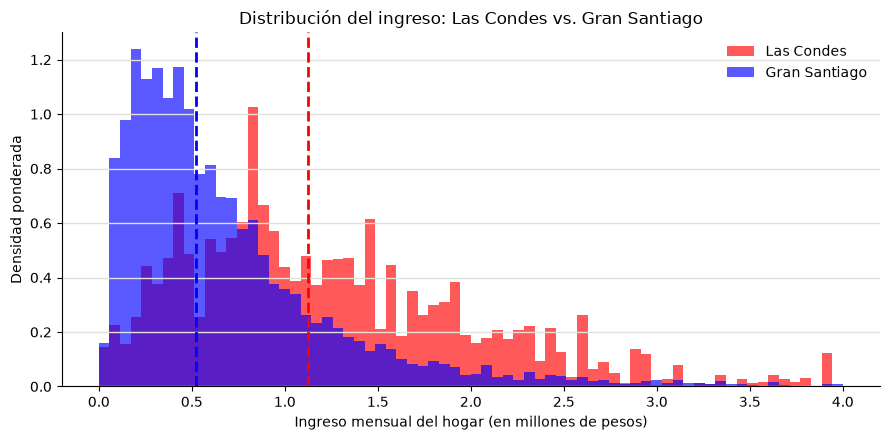

In [442]:
hogaresLC_limpio = hogaresLasCondes[["IngresoHogar", "Factor"]].dropna()
hogaresLC_limpio = hogaresLC_limpio[hogaresLC_limpio["Factor"] > 0]
hogares_limpio = hogares[["IngresoHogar", "Factor"]].dropna()
hogares_limpio = hogares_limpio[hogares_limpio["Factor"] > 0]

ingresosLasCondes = hogaresLC_limpio["IngresoHogar"].values / 1e6
ingresos = hogares_limpio["IngresoHogar"].values / 1e6
weightsLasCondes = hogaresLC_limpio["Factor"].values
weights = hogares_limpio["Factor"].values

medLC = cuantiles_ponderados(hogaresLC_limpio["IngresoHogar"], hogaresLC_limpio["Factor"], 0.50) / 1e6
medGS = cuantiles_ponderados(hogares_limpio["IngresoHogar"], hogares_limpio["Factor"], 0.50) / 1e6

fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(0, 4, 71)
colorLC = "red"
colorGS = "blue"

ax.hist(ingresosLasCondes, bins=bins, weights=weightsLasCondes, density=True,
        alpha=0.65, color=colorLC, edgecolor="none",
        label="Las Condes")
ax.hist(ingresos, bins=bins, weights=weights, density=True,
        alpha=0.65, color=colorGS, edgecolor="none",
        label="Gran Santiago")

ax.axvline(medLC, color=colorLC, lw=2, ls="--")
ax.axvline(medGS, color=colorGS, lw=2, ls="--")

ax.set_xlabel("Ingreso mensual del hogar (en millones de pesos)")
ax.set_ylabel("Densidad ponderada")
ax.set_title("Distribución del ingreso: Las Condes vs. Gran Santiago")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=1)
plt.tight_layout()
plt.show()

**Interpretación:** Las Condes muestra una concentración de hogares en ingresos medios-altos (con una mediana de ~$1.2M) con una cola derecha más larga que llega hasta $4M, mientras que Gran Santiago se concentra más a la izquierda (mediana ~$0.5M). El hecho de que la mediana de Las Condes supere al doble a la de la ciudad, sumado a una mayor proporción de hogares con ingresos mayores a los $2M, indica una estructura socioeconómica más privilegiada.

### 6. La comuna de contraste (8 pts)

**Instrucciones**

Elijan una comuna con un perfil de movilidad distinto al de la suya y
justifiquen la elección con datos; una cifra basta.

Calculen el reparto modal ponderado de las tres unidades: su comuna, la de
contraste y el Gran Santiago. El modo de cada viaje está en `ViajesDifusion.csv`
(llave `Viaje`) y su catálogo en `tablas_parametros/ModoDifusion.csv`; un viaje
pertenece a la comuna de su origen y el peso es `FactorLaboralNormal`.

Muestren las tres unidades en una sola figura.

En la interpretación, lean el contraste entre las tres unidades.

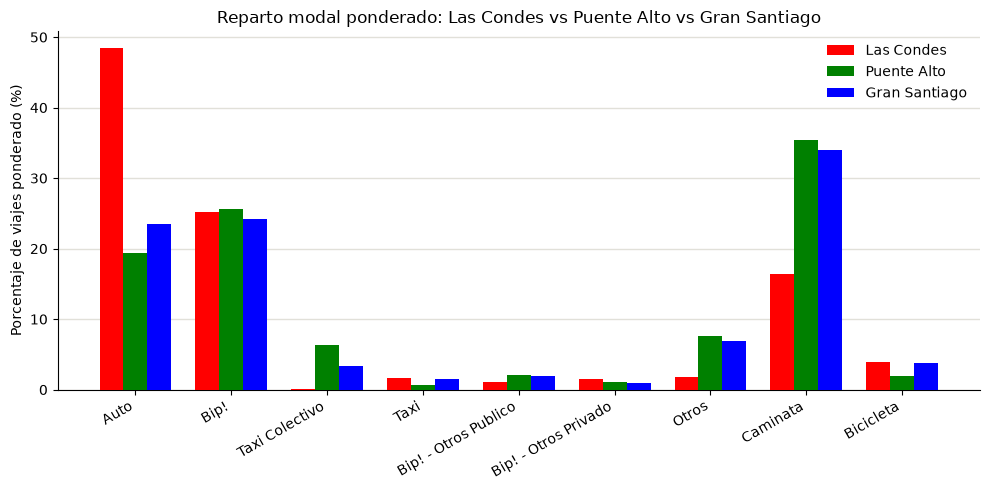

                      Las Condes  Puente Alto  Gran Santiago
Auto                        48.4         19.3           23.4
Bip!                        25.2         25.6           24.2
Taxi Colectivo               0.1          6.3            3.4
Taxi                         1.7          0.6            1.6
Bip! - Otros Publico         1.2          2.1            1.9
Bip! - Otros Privado         1.5          1.1            0.9
Otros                        1.8          7.6            6.9
Caminata                    16.3         35.4           33.9
Bicicleta                    3.9          2.0            3.8


In [443]:
modoCatalogo = pd.read_csv(RUTA + "tablas_parametros/ModoDifusion.csv", sep=";")
comunaCatalogo = pd.read_csv(RUTA + "tablas_parametros/Comuna.csv", sep=",")
viajes = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";")

v = viajes_lab.merge(viajes, on="Viaje", how="left") \
              .merge(modoCatalogo, left_on="ModoDifusion", right_on="ID", how="left") \
              .merge(comunaCatalogo, left_on="ComunaOrigen", right_on="Id", how="left")

unidades = {
    "Las Condes":    v[v["Comuna"] == "LAS CONDES"],
    "Puente Alto":   v[v["Comuna"] == "PUENTE ALTO"],
    "Gran Santiago": v
}
modosOrden = modoCatalogo["ModoDifusion"].tolist()
tablaModos = pd.DataFrame(index=modosOrden, dtype=float)

for nombre, df in unidades.items():
    if len(df) == 0 or df["FactorLaboralNormal"].sum() == 0:
        tablaModos[nombre] = 0.0
        continue
    total = df["FactorLaboralNormal"].sum()
    pesos_modo = df.groupby("ModoDifusion_y")["FactorLaboralNormal"].sum()
    tablaModos[nombre] = (pesos_modo / total * 100).reindex(modosOrden, fill_value=0.0)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(modosOrden))
ancho = 0.25
colores = ["red", "green", "blue"]

for i, (nombre, color) in enumerate(zip(["Las Condes", "Puente Alto", "Gran Santiago"], colores)):
    ax.bar(x + (i - 1) * ancho, tablaModos[nombre], ancho,
           color=color, edgecolor="none", label=nombre, zorder=3)

ax.set_ylabel("Porcentaje de viajes ponderado (%)")
ax.set_title("Reparto modal ponderado: Las Condes vs Puente Alto vs Gran Santiago")
ax.set_xticks(x)
ax.set_xticklabels(modosOrden, rotation=30, ha="right")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e1e0d9", lw=1)
plt.tight_layout()
plt.show()

print(tablaModos.round(1))

**Interpretación:** En Las Condes, el uso de auto es por lejos la forma más popular de movilizarse concentrando casi un 50% de todos los viajes hechos en la comuna. La cifra suena aún más arrolladora cuando se contrasta con Puente Alto o el Gran Santiago, en donde los viajes en auto a penas llegan al ~20% y ~25% respectivamente. Además, se puede ver que el uso de bicicleta en Las Condes duplica el uso en Puente Alto, lo cual tiene sentido al considerar que el nivel socioeconómico de la primera comuna le permite invertir en la construcción de ciclovías y más áreas verdes. Por otro lado, Puente Alto hace mucho más uso de las caminatas (~35% vs ~15%) y taxis colectivos (~7% vs ~1%). El uso de Bip! es muy parecido en las 2 comunas y en el Gran Santiago.

### 7. Ingreso y transporte público (8 pts)

**Instrucciones**

Para todas las comunas del Gran Santiago calculen dos series: el ingreso medio
ponderado de los hogares (`IngresoHogar` con `Factor`) y la proporción ponderada
de viajes en transporte público. Decidan qué modos de `ModoDifusion` cuentan
como transporte público y declárenlo; el peso de los viajes es
`FactorLaboralNormal`.

Grafiquen una serie contra la otra, con cada comuna como un punto, destacando la
suya y la de contraste. Calculen las correlaciones de Pearson y de Spearman
entre ambas series.

En la interpretación: ¿qué indica la diferencia entre los dos coeficientes?
¿Qué comunas se apartan del patrón general, y dónde queda la suya?

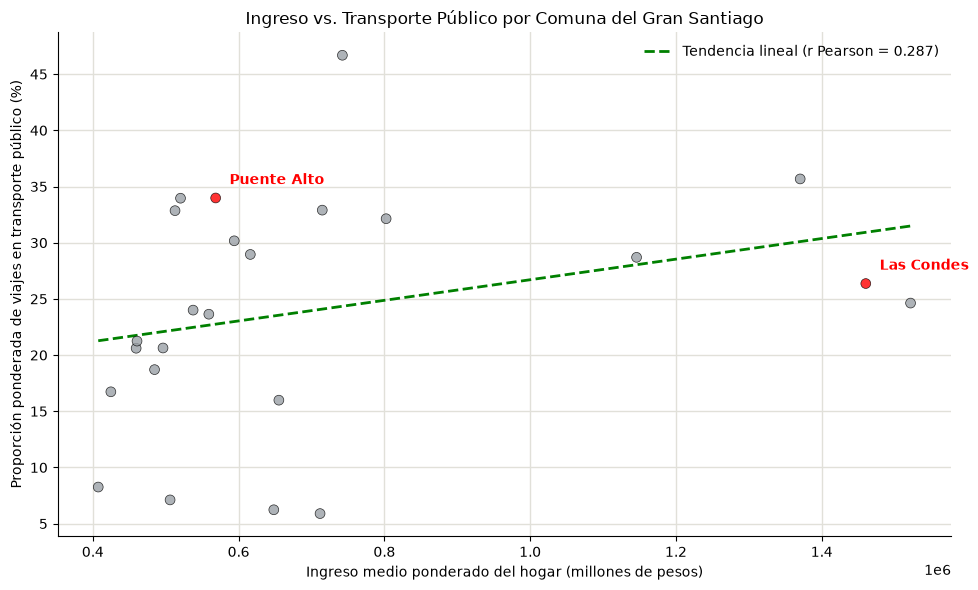

Correlación de Pearson: 0.2871
Correlación de Spearman: 0.4252


In [444]:
# 2 = Bip!,  3 = Taxi Colectivo,  5 = Bip! - Otros Publico
MODOS_PUBLICOS = [2, 3, 5]
GRAN_SANTIAGO_IDS = list(range(70, 103))
v_gs = v[v["Id"].isin(GRAN_SANTIAGO_IDS)].copy()

hogares_lab = hogares.dropna(subset=["Factor"])
hogares_con_ingreso = hogares_lab[hogares_lab["Factor"] > 0].copy()
ingreso_comuna = hogares_con_ingreso.groupby("Comuna").apply(
    lambda d: (d["IngresoHogar"] * d["Factor"]).sum() / d["Factor"].sum()
)

viajes_publicos_gs = v_gs[v_gs["ModoDifusion_x"].isin(MODOS_PUBLICOS)]

viajes_por_comuna = v_gs.groupby("Comuna")["FactorLaboralNormal"].sum()
viajes_publicos_por_comuna = viajes_publicos_gs.groupby("Comuna")["FactorLaboralNormal"].sum()
prop_publico = (viajes_publicos_por_comuna / viajes_por_comuna) * 100

resultado = pd.DataFrame({
    "IngresoMedio": ingreso_comuna,
    "ProporcionTransportePublico": prop_publico
}).dropna()

resultado["Destacar"] = resultado.index.isin(["LAS CONDES", "PUENTE ALTO"])

r_pearson, _ = pearsonr(resultado["IngresoMedio"], resultado["ProporcionTransportePublico"])
r_spearman, _ = spearmanr(resultado["IngresoMedio"], resultado["ProporcionTransportePublico"])


fig, ax = plt.subplots(figsize=(10, 6))
colors = ["red" if d else "#9aa0a6" for d in resultado["Destacar"]]

ax.scatter(
    resultado["IngresoMedio"],
    resultado["ProporcionTransportePublico"],
    c=colors, s=50, alpha=0.8,
    edgecolors="black", linewidth=0.5, zorder=3
)

for idx, row in resultado[resultado["Destacar"]].iterrows():
    ax.annotate(
        idx.title(),
        (row["IngresoMedio"], row["ProporcionTransportePublico"]),
        textcoords="offset points", xytext=(10, 10),
        fontsize=10, fontweight="bold", color="red"
    )

x = resultado["IngresoMedio"].values
y = resultado["ProporcionTransportePublico"].values
sorted_idx = np.argsort(x)
x_sorted = x[sorted_idx]
y_sorted = y[sorted_idx]

coef_lin = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, np.polyval(coef_lin, x_line), color="green", lw=2, ls="--",
        label=f"Tendencia lineal (r Pearson = {r_pearson:.3f})")

ax.set_xlabel("Ingreso medio ponderado del hogar (millones de pesos)")
ax.set_ylabel("Proporción ponderada de viajes en transporte público (%)")
ax.set_title("Ingreso vs. Transporte Público por Comuna del Gran Santiago")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="both", color="#e1e0d9", lw=1)
plt.tight_layout()
plt.show()

print(f"Correlación de Pearson: {r_pearson:.4f}")
print(f"Correlación de Spearman: {r_spearman:.4f}")

**Interpretación:** Este gráfico muestra una correlación positiva débil ($r = 0.287$) entre el ingreso del hogar y el uso del transporte público en el Gran Santiago. Existe una gran dispersión en comunas de menores ingresos, donde el uso varía drásticamente (del ~6% al ~47%). Destaca Puente Alto con un uso alto (~34%) para su nivel de ingreso, mientras Las Condes registra un uso moderado (~26.5%) pese a tener el ingreso más alto, reflejando que la conectividad y el acceso al Metro pesan tanto como el nivel socioeconómico.

### 8. Un hallazgo propio (6 pts)

**Instrucciones**

Agreguen un gráfico a elección que muestre algo del retrato que los ítems
anteriores no capturan, ponderado como todo lo demás. Se evalúa que el hallazgo
no sea trivial: que no repita lo ya visto ni muestre algo obvio.

En la interpretación, escriban la lectura del hallazgo en dos o tres líneas.

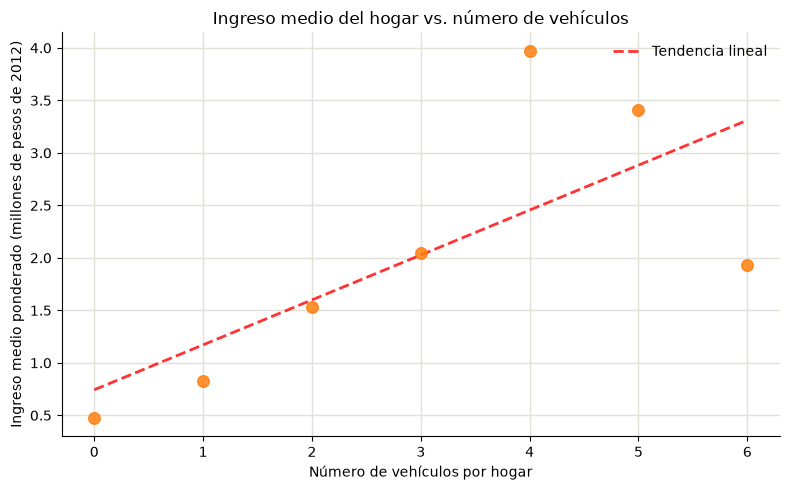

Ingreso medio ponderado por cantidad de vehículos:
num_vehiculos
0     473523
1     826685
2    1529909
3    2047043
4    3973277
5    3411098
6    1929844
dtype: int64


In [445]:
vehiculos = pd.read_csv(RUTA + "Vehiculo.csv", sep=";", decimal=",", encoding="latin-1", low_memory=False)
num_vehiculos = vehiculos.groupby("Hogar").size().rename("num_vehiculos")

ho = hogares[["Hogar", "IngresoHogar", "Factor"]].dropna()
ho = ho[ho["Factor"] > 0]
ho = ho.merge(num_vehiculos, on="Hogar", how="left")
ho["num_vehiculos"] = ho["num_vehiculos"].fillna(0).astype(int)

resumen = ho.groupby("num_vehiculos").apply(
    lambda d: (d["IngresoHogar"] * d["Factor"]).sum() / d["Factor"].sum(),
    include_groups=False
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(resumen.index, resumen.values / 1e6,
           color="tab:orange", s=70, alpha=0.85, zorder=3)

coef = np.polyfit(resumen.index, resumen.values / 1e6, 1)
x_line = np.linspace(resumen.index.min(), resumen.index.max(), 100)
ax.plot(x_line, np.polyval(coef, x_line),
        color="red", lw=2, ls="--", alpha=0.8, label="Tendencia lineal")

ax.set_xlabel("Número de vehículos por hogar")
ax.set_ylabel("Ingreso medio ponderado (millones de pesos de 2012)")
ax.set_title("Ingreso medio del hogar vs. número de vehículos")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="both", color="#e1e0d9", lw=1)
plt.tight_layout()
plt.show()

print("Ingreso medio ponderado por cantidad de vehículos:")
print(resumen.round(0).astype(int))

**Interpretación:** El gráfico de dispersión muestra una relación no lineal entre el ingreso del hogar y el número de vehículos por hogar. Los hogares sin vehículos tienen un ingreso medio de $473.523, mientras que los hogares con 4 vehículos alcanzan el ingreso máximo de $3.973.277. Sin embargo, para hogares con 5 o más vehículos, el ingreso tiende a disminuir ligeramente. Esto podría reflejar que la posesión de vehículos inicialmente aumenta con el ingreso, pero en los niveles más altos, otros factores (como tamaño familiar, preferencias de transporte o limitaciones de estacionamiento) influyen en la decisión de adquirir más vehículos. La tendencia general muestra que hasta cierto punto, más vehículos están asociados con mayores ingresos, pero la relación no es estrictamente lineal.

## Parte 3. Decisiones sobre los datos (25 puntos)

### 9. Los que faltan (8 pts)

**Instrucciones**

Identifiquen los datos faltantes que afectan su retrato: al menos
`IngresoHogar`, los factores de expansión, `TiempoViaje` y las coordenadas.
Determinen si esos faltantes siguen algún patrón (por ejemplo, si se concentran
en algún grupo o comuna) o si pueden tratarse como ausencias sin estructura, y
muestren la evidencia. Recuerden lo visto en clase: un `NaN` en los factores no
es un error, significa que esa persona no pertenece a ese universo.

Declaren qué decidieron hacer con los faltantes y recalculen una de las cifras
de su retrato con la decisión contraria, para mostrar cuánto cambia.

In [ ]:
coord_cols = ["OrigenCoordX", "OrigenCoordY", "DestinoCoordX", "DestinoCoordY"]

# 71 es el ID de Las Condes
viajes_lc = viajes_lab[viajes_lab["ComunaOrigen"] == 71] 

n_viajes_stgo = len(viajes_lab)
n_tiempo_stgo = (viajes_lab["TiempoViaje"].isna() | (viajes_lab["TiempoViaje"] <= 0)).sum()
n_coord_stgo = viajes_lab[coord_cols].isna().any(axis=1).sum()


n_viajes_lc = len(viajes_lc)
n_tiempo_lc = (viajes_lc["TiempoViaje"].isna() | (viajes_lc["TiempoViaje"] <= 0)).sum()
n_coord_lc = viajes_lc[coord_cols].isna().any(axis=1).sum()

tabla_faltantes = pd.DataFrame({
    "Variable analizada": [
        "IngresoHogar (Hogares)",
        "Factor de expansión (Hogares / Personas)",
        "Tiempo de viaje (TiempoViaje)",
        "Coordenadas geográficas"
    ],
    "Gran Santiago (Faltantes)": [
        f"{hogares['IngresoHogar'].isna().sum()} hogares (0.0%)",
        f"{hogares['Factor'].isna().sum()} en hogares | {personas['Factor'].isna().sum()} en personas",
        f"{n_tiempo_stgo:,} viajes ({n_tiempo_stgo/n_viajes_stgo:.2%})",
        f"{n_coord_stgo:,} viajes ({n_coord_stgo/n_viajes_stgo:.1%})"
    ],
    "Las Condes (Faltantes)": [
        f"{hogaresLasCondes['IngresoHogar'].isna().sum()} hogares (0.0%)",
        f"{hogaresLasCondes['Factor'].isna().sum()} en hogares | {personas[personas['Hogar'].isin(hogaresLasCondes['Hogar'])]['Factor'].isna().sum()} en personas",
        f"{n_tiempo_lc} viajes ({n_tiempo_lc/n_viajes_lc:.2%})",
        f"{n_coord_lc} viajes ({n_coord_lc/n_viajes_lc:.1%})"
    ]
})

display(tabla_faltantes)

# Recálculo bajo decisión contraria:
# Decisión original: Mantener los hogares con ingreso $0 en el cálculo del ingreso medio.
# Decisión contraria: Excluir los hogares con IngresoHogar == 0 como datos faltantes.

media_con_ceros = (hogaresLasCondes["IngresoHogar"] * hogaresLasCondes["Factor"]).sum() / hogaresLasCondes["Factor"].sum()

hogares_lc_sin_ceros = hogaresLasCondes[hogaresLasCondes["IngresoHogar"] > 0]
media_sin_ceros = (hogares_lc_sin_ceros["IngresoHogar"] * hogares_lc_sin_ceros["Factor"]).sum() / hogares_lc_sin_ceros["Factor"].sum()

comparacion_decision = pd.DataFrame({
    "Estrategia sobre ingresos $0": [
        "Mantener ceros (Decisión original)",
        "Excluir ceros (Decisión contraria)"
    ],
    "Hogares considerados": [
        len(hogaresLasCondes),
        len(hogares_lc_sin_ceros)
    ],
    "Ingreso medio ponderado": [
        f"${media_con_ceros:,.0f}",
        f"${media_sin_ceros:,.0f}"
    ]
})

display(comparacion_decision)

,Variable analizada,Gran Santiago (Faltantes),Las Condes (Faltantes)
0,IngresoHogar (Hogares),0 hogares (0.0%),0 hogares (0.0%)
1,Factor de expansión (Hogares / Personas),0 en hogares | 0 en personas,0 en hogares | 0 en personas
2,Tiempo de viaje (TiempoViaje),362 viajes (0.46%),11 viajes (0.22%)
3,Coordenadas geográficas,"13,121 viajes (16.6%)",345 viajes (6.9%)


,Estrategia sobre ingresos $0,Hogares considerados,Ingreso medio ponderado
0,Mantener ceros (Decisión original),888,"$1,460,452"
1,Excluir ceros (Decisión contraria),883,"$1,469,351"


**Interpretación:** El diagnóstico de datos faltantes muestra que variables como el ingreso y los factores de expansión no presentan registros nulos al utilizar el factor general de hogares y personas (aunque se identifican 5 hogares en Las Condes con ingresos de $0 que actúan como omisiones involuntarias), mientras que el tiempo de viaje registra ausencias aleatorias (0,22% en Las Condes).

Por el contrario, las coordenadas geográficas muestran una pérdida de información estructurada que afecta al 6,9% de los viajes de la comuna (y al 16,6% del Gran Santiago), concentrándose mayoritariamente en zonas periféricas. Al evaluar una decisión contraria sobre los hogares con ingreso $0 —excluyéndolos en lugar de mantenerlos—, el ingreso medio ponderado de Las Condes pasa de $1.460.452 (considerando 888 hogares) a $1.469.351 (considerando 883 hogares), lo que representa una variación mínima de +$8.899 (+0,61%), demostrando que el indicador central comunal es sumamente robusto frente a esta decisión de limpieza.

### 10. Los extremos (8 pts)

**Instrucciones**

Busquen valores extremos o sospechosos en las duraciones (`TiempoViaje`) y en
las distancias de los viajes con origen en su comuna. La distancia está en
`DistanciaViaje.csv`, con llave `Viaje` y expresada en metros.

Cuantifíquenlos con algún criterio explícito: la regla de Tukey del boxplot, el
criterio de desviaciones estándar respecto de la media (por ejemplo, tres
sigmas), u otro que conozcan y justifiquen.

Investíguenlos: ¿son errores de registro o viajes reales posibles? Declaren la
decisión que tomaron (mantener, corregir o excluir) y muestren su efecto sobre
las medidas que reportaron, por ejemplo comparando la media y la mediana con y
sin ellos.

In [447]:
# Su código (agreguen las celdas que necesiten)


**Interpretación:** *(reemplacen este texto por su respuesta)*

### 11. Una transformación (9 pts)

**Instrucciones**

Apliquen una transformación justificada a una variable de su retrato, por
ejemplo el logaritmo al ingreso o a la duración.

Muestren el efecto con un gráfico del antes y el después.

En la interpretación, expliquen cómo cambia la forma de la distribución y qué
medidas se vuelven más o menos informativas después de la transformación.

<Figure size 640x480 with 0 Axes>

Mediana original  Las Condes: $1.13M  |  Gran Santiago: $0.52M
Mediana sqrt      Las Condes: 1.061  |  Gran Santiago: 0.721
Media original    Las Condes: $1,460,452
Media original    Gran Santiago: $729,898


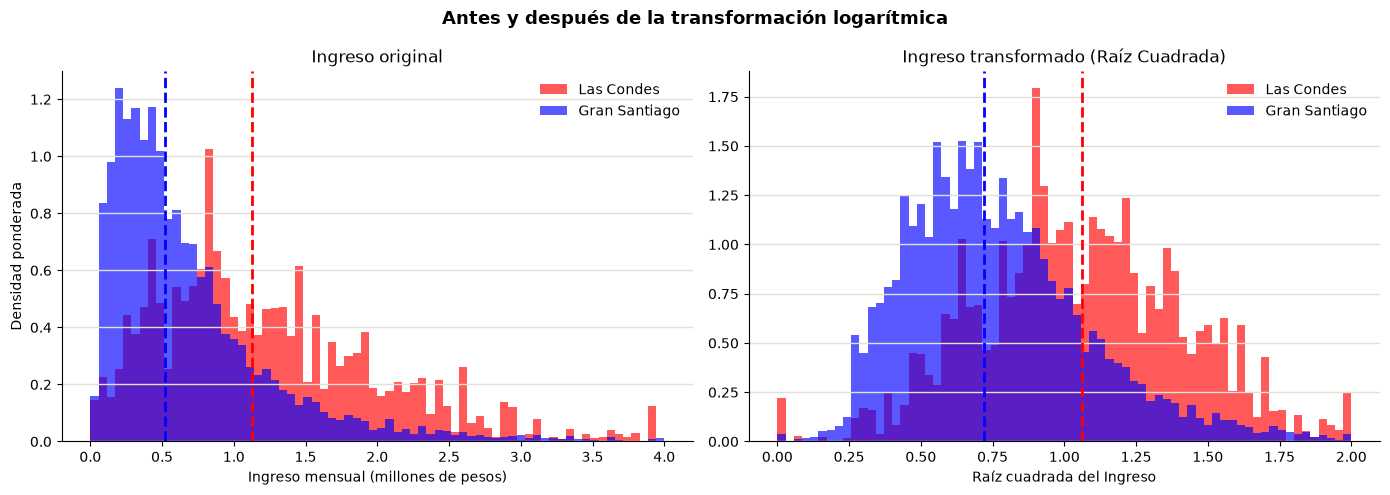

In [448]:

hogaresLC_limpio = hogaresLasCondes[["IngresoHogar", "Factor"]].dropna()
hogaresLC_limpio = hogaresLC_limpio[hogaresLC_limpio["Factor"] > 0]
hogares_limpio = hogares[["IngresoHogar", "Factor"]].dropna()
hogares_limpio = hogares_limpio[hogares_limpio["Factor"] > 0]

ingresosLC = hogaresLC_limpio["IngresoHogar"].values / 1e6
ingresos = hogares_limpio["IngresoHogar"].values / 1e6
pesosLC = hogaresLC_limpio["Factor"].values
pesos = hogares_limpio["Factor"].values

medLC_original = cuantiles_ponderados(hogaresLC_limpio["IngresoHogar"], hogaresLC_limpio["Factor"], 0.50) / 1e6
med_original = cuantiles_ponderados(hogares_limpio["IngresoHogar"], hogares_limpio["Factor"], 0.50) / 1e6
medLC_sqrt = cuantiles_ponderados(np.sqrt(hogaresLC_limpio["IngresoHogar"] / 1e6), hogaresLC_limpio["Factor"], 0.50)
med_sqrt = cuantiles_ponderados(np.sqrt(hogares_limpio["IngresoHogar"] / 1e6), hogares_limpio["Factor"], 0.50)

sqrt_bins = np.linspace(0, np.sqrt(4), 71)
ax2.hist(np.sqrt(ingresosLC), bins=sqrt_bins, weights=pesosLC, density=True,
         alpha=0.65, color="red", edgecolor="none", label="Las Condes")
ax2.hist(np.sqrt(ingresos), bins=sqrt_bins, weights=pesos, density=True,
         alpha=0.65, color="blue", edgecolor="none", label="Gran Santiago")

ax2.axvline(medLC_sqrt, color="red", lw=2, ls="--")
ax2.axvline(med_sqrt, color="blue", lw=2, ls="--")

ax2.set_xlabel("Raíz cuadrada del Ingreso (en millones)")
ax2.set_ylabel("Densidad ponderada")
ax2.set_title("Ingreso transformado (Raíz Cuadrada)")
ax2.legend(frameon=False)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", color="#e1e0d9", lw=1)

plt.suptitle("Antes y después de la transformación de raíz cuadrada", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Mediana original  Las Condes: ${medLC_original:,.2f}M  |  Gran Santiago: ${med_original:,.2f}M")
print(f"Mediana sqrt      Las Condes: {medLC_sqrt:.3f}  |  Gran Santiago: {med_sqrt:.3f}")
print(f"Media original    Las Condes: ${(hogaresLC_limpio['IngresoHogar'] * hogaresLC_limpio['Factor']).sum() / hogaresLC_limpio['Factor'].sum():,.0f}")
print(f"Media original    Gran Santiago: ${(hogares_limpio['IngresoHogar'] * hogares_limpio['Factor']).sum() / hogares_limpio['Factor'].sum():,.0f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 4, 71)

# Panel izquierdo: ingreso original
ax1.hist(ingresosLC, bins=bins, weights=pesosLC, density=True,
         alpha=0.65, color="red", edgecolor="none", label="Las Condes")
ax1.hist(ingresos, bins=bins, weights=pesos, density=True,
         alpha=0.65, color="blue", edgecolor="none", label="Gran Santiago")
ax1.axvline(medLC_original, color="red", lw=2, ls="--")
ax1.axvline(med_original, color="blue", lw=2, ls="--")
ax1.set_xlabel("Ingreso mensual (millones de pesos)")
ax1.set_ylabel("Densidad ponderada")
ax1.set_title("Ingreso original")
ax1.legend(frameon=False)
ax1.spines[["top", "right"]].set_visible(False)
ax1.grid(axis="y", color="#e1e0d9", lw=1)

sqrt_bins = np.linspace(0, np.sqrt(4), 71)
ax2.hist(np.sqrt(ingresosLC), bins=sqrt_bins, weights=pesosLC, density=True,
         alpha=0.65, color="red", edgecolor="none", label="Las Condes")
ax2.hist(np.sqrt(ingresos), bins=sqrt_bins, weights=pesos, density=True,
         alpha=0.65, color="blue", edgecolor="none", label="Gran Santiago")
ax2.axvline(medLC_sqrt, color="red", lw=2, ls="--")
ax2.axvline(med_sqrt, color="blue", lw=2, ls="--")
ax2.set_xlabel("Raíz cuadrada del Ingreso")
ax2.set_title("Ingreso transformado (Raíz Cuadrada)")
ax2.legend(frameon=False)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", color="#e1e0d9", lw=1)

plt.suptitle("Antes y después de la transformación logarítmica", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretación:** La transformación de raíz cuadrada corrige la fuerte asimetría positiva del ingreso, comprimiendo los valores extremos para lograr una distribución más cercana a la distribución normal. En los datos originales, la mediana es la medida más informativa al no distorsionarse por los hogares muy ricos, mientras que a la media le falta representatividad. Luego de transformar los datos, la media y la desviación estándar recuperan su utilidad estadística, acercándose a un comportamiento normal que facilita evidenciar cómo el ingreso típico de Las Condes supera ampliamente al resto del Gran Santiago.

## Parte 4. Síntesis (20 puntos)

### 12. El retrato (8 pts)

**Instrucciones**

- Escriban aquí "El retrato de [su comuna]" en **máximo 10 líneas**, integrando
  los hallazgos numéricos y gráficos de toda la tarea.
- Debe poder leerse sola, sin el resto del notebook: con cifras concretas, no
  con referencias a "el gráfico anterior".

*El retrato de Las Condes muestra una comuna de altos ingresos y bajo uso de transporte público. 
888 hogares encuestados representan 103,108 hogares (Factor medio ≈116). 
2,253 personas encuestadas representan 309,184 personas. 
Edad mediana: 36 años (percentiles 21-54), ligeramente superior a Gran Santiago (34, 18-52). 
Ingreso mediano ponderado: $1.125 millones (media $1.460 millones), más del doble que en el área metropolitana ($520.000). 
Distribución de ingreso sesgada a la derecha; mediana más representativa que la media. 
~50% de los viajes se realizan en auto (vs ~20-25% en Puente Alto y Gran Santiago). 
Correlación débil positiva entre ingreso y uso transporte público (r de Pearson ≈0.29). 
La tenencia de vehículos muestra ingreso máximo con 4 autos (~$4.0 millones), relación no lineal. 
Estos indicadores reflejan una estructura socioeconómica privilegiada con alta motorización y baja dependencia del transporte público.*

### 13. ¿De quién hablan sus números? (6 pts)

**Instrucciones**

- ¿Sus cifras hablan de la muestra, de su comuna, de la ciudad? ¿De qué días y
  temporada, dado el universo que declararon?
- ¿Qué personas o viajes podrían estar quedando fuera del retrato? Piensen en
  quién responde una encuesta presencial de 2012 y quién no.

*(reemplacen este texto por su respuesta)*

### 14. Una hipótesis para más adelante (6 pts)

**Instrucciones**

- Formulen una hipótesis **verificable** que su exploración sugiere pero no
  demuestra (por ejemplo, sobre la relación entre dos variables de su comuna).
- Se evalúa que sea precisa, comprobable y motivada por sus datos. 



In [449]:
# Reemplacen este texto por su hipotesis y su motivacion en 2 a 4 lineas.

## Declaración de uso de IA generativa

*(reemplacen este texto: qué herramienta usaron y para qué; una línea basta.
Recuerden que deben poder explicar cualquier línea de su código si se les
pregunta en clase.)*

## Antes de entregar

- [ ] El notebook corre de principio a fin sin errores.
- [ ] `MI_COMUNA` y `COMUNA_CONTRASTE` están definidas.
- [ ] Toda cifra poblacional está ponderada y su universo está declarado.
- [ ] Todos los gráficos tienen título y ejes rotulados con unidades.
- [ ] Todas las celdas de "Interpretación" están completas.
- [ ] El archivo se llama `tarea1_apellido1_apellido2.ipynb`.
- [ ] La declaración de uso de IA está completa.